In [ ]:
!pip install pandas

In [5]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 17.6 MB/s eta 0:00:00m eta 0:00:01:01


In [ ]:
!pip install pm4py

In [ ]:
!pip install matplotlib

In [ ]:
!pip install seaborn

In [1]:
import pandas as pd
import pm4py
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from datetime import timedelta
import warnings
import numpy as np
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_visualization
from pm4py.util import constants
warnings.filterwarnings('ignore')

# Visualization configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
COLORS = {'primary': '#2E86AB', 'secondary': '#A23B72', 'accent': '#F18F01', 
          'success': '#C73E1D', 'neutral': '#3B1F2B'}

## 1. Preprocessing

###1.1 Formatting columns for the compatibility with pm4py

In [2]:
from preprocessor import standardize_dataframe_for_pm4py

df = pd.read_csv("../event_log.csv")
complete_log = standardize_dataframe_for_pm4py(df)


### 1.2 Checking for missing data in case level attributes

In [4]:
case_attributes = [
    "case:concept:name",
    "case:arrival_transport",
    "case:disposition",
    "case:gender",
    "case:race",
    "case:acuity",
    "case:chiefcomplaint"
]


# Group by Case ID and take the first value found
grouped_by_case_log = complete_log[case_attributes].groupby("case:concept:name").first()

# 1. Basic Counts and Percentages
missing_count = grouped_by_case_log.isnull().sum()
missing_pct = (grouped_by_case_log.isnull().sum() / len(grouped_by_case_log)) * 100

# Combine into a clear report
missing_report = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage': missing_pct
}).sort_values(by='Percentage', ascending=False)

print(missing_report)

                        Missing Values  Percentage
case:acuity                         56    3.076923
case:arrival_transport               0    0.000000
case:disposition                     0    0.000000
case:gender                          0    0.000000
case:race                            0    0.000000
case:chiefcomplaint                  0    0.000000


### 1.3 Handling missing data in case level attributes
Case-level missing data analysis showed very low missingness across most attributes. Only acuity exhibited moderate missingness (3.08%), which was handled by introducing an explicit ‘Unknown’ category to avoid clinically unjustified imputation. Diagnosis-related attributes had negligible missingness (<0.2%) and were retained, with missing values flagged for downstream attribute-based analyses.

### 1.4 Case-Level Coverage of Activity Attributes

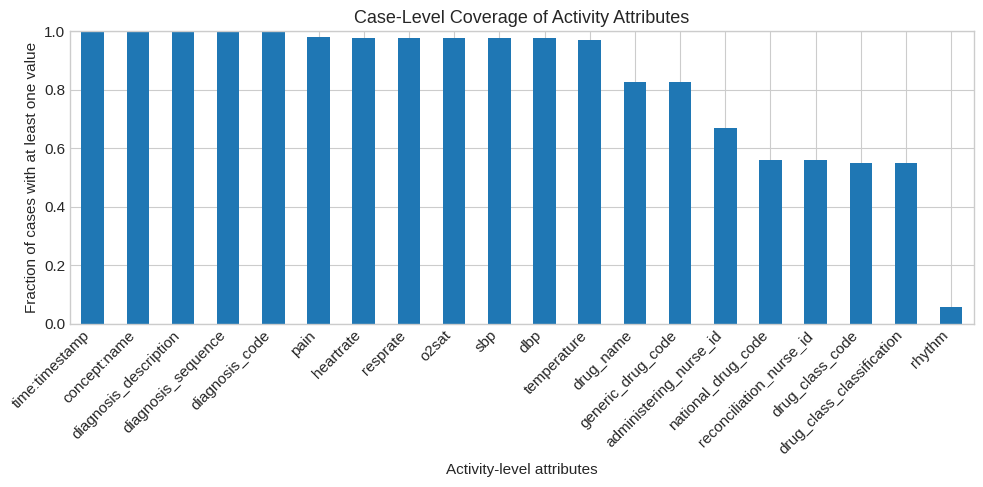

time:timestamp               1.000000
concept:name                 1.000000
diagnosis_description        0.998352
diagnosis_sequence           0.998352
diagnosis_code               0.998352
pain                         0.980769
heartrate                    0.978022
resprate                     0.978022
o2sat                        0.978022
sbp                          0.977473
dbp                          0.977473
temperature                  0.970879
drug_name                    0.828022
generic_drug_code            0.826374
administering_nurse_id       0.669231
national_drug_code           0.560989
reconciliation_nurse_id      0.560989
drug_class_code              0.548901
drug_class_classification    0.548901
rhythm                       0.057692
dtype: float64

In [5]:
activity_attributes = list(set(complete_log.columns) - set(case_attributes))
attr_coverage = (
    complete_log
    .groupby("case:concept:name")[activity_attributes]
    .apply(lambda x: x.notna().any())
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
attr_coverage.plot(kind="bar")
plt.ylabel("Fraction of cases with at least one value")
plt.xlabel("Activity-level attributes")
plt.title("Case-Level Coverage of Activity Attributes")
plt.xticks(rotation=45, ha="right")
plt.ylim(0,1)
plt.tight_layout()
plt.show()
attr_coverage

We analyzed missing activity-level attributes using a case-aware approach, measuring the fraction of cases in which each attribute was observed at least once. This analysis revealed that many attributes, such as vital signs and medication-related fields, are conditionally or event-specifically recorded, meaning their absence does not indicate data quality issues. Since process discovery and performance analysis rely solely on activity names and timestamps, no activity attributes were removed or imputed at this stage. Preserving missing values is essential to avoid introducing clinically unjustified assumptions and to enable correct pattern-based feature generation in later analysis stages.

### 1.5 Detect backward timestamps within cases (temporal anomalies).


In [5]:
from data_validation import detect_temporal_anomalies

detect_temporal_anomalies(complete_log)


STEP 2: TEMPORAL ANOMALIES DETECTION

    Checking for backward timestamps within cases...
    A temporal anomaly = event where timestamp goes backward in time.
    
✓ RESULT: No temporal anomalies detected
  All timestamps are in chronological order within each case.


""


### 1.6 Check for violations of expected clinical sequences in the ED process

In [31]:
from data_validation import validate_domain_order
validate_domain_order(complete_log)


STEP 4: DOMAIN-BASED ORDER VALIDATION

    Validating expected clinical sequences based on ED domain knowledge...

    Expected precedence rules:
    1. 'Enter the ED' → should be FIRST activity in every case
    2. 'Enter the ED' → 'Triage in the ED' (entry before triage)
    3. 'Triage in the ED' → 'Medicine administration' (triage before treatment)
    4. Any activity → 'Discharge from the ED' (discharge should be LAST)
    

✓ RESULTS:
  Start activities: {'Enter the ED': 1820}
  End activities: {'Discharge from the ED': 1820}

  ✓ No domain-based order violations detected!
    All cases follow the expected clinical sequence.

  Process boundary validation:
    ✓ All cases start with 'Enter the ED'
    ✓ All cases end with 'Discharge from the ED'


(Empty DataFrame
 Columns: []
 Index: [],
 {'Enter the ED': 1820},
 {'Discharge from the ED': 1820})

from data_validation import detect_concurrent_activities,create_concurrent_heatmap

concurrent_df, concurrent_cases, concurrent_pairs = detect_concurrent_activities(complete_log)
create_concurrent_heatmap(concurrent_pairs, complete_log)


STEP 3: CONCURRENT/PARALLEL ACTIVITIES DETECTION

    Identifying events at exactly the same timestamp within cases...
    Concurrent activities indicate parallel execution or batch recording.
    

✓ RESULTS:
  - Cases with concurrent activities: 1,612 / 1,820 (88.6%)
  - Total concurrent activity groups: 4,362
  - Average activities per concurrent group: 3.00
  - Maximum concurrent activities: 43

  Top 10 most common concurrent activity pairs:
    Medicine reconciliation ‖ Medicine reconciliation: 16,692 times
    Medicine dispensations ‖ Medicine dispensations: 3,936 times
    Discharge from the ED ‖ Discharge from the ED: 2,948 times
    Enter the ED ‖ Vital sign check: 363 times
    Medicine reconciliation ‖ Vital sign check: 113 times
    Medicine dispensations ‖ Vital sign check: 34 times
    Medicine dispensations ‖ Medicine reconciliation: 30 times
    Enter the ED ‖ Medicine dispensations: 2 times

    INTERPRETATION:
    - High concurrency suggests batch recording or paral

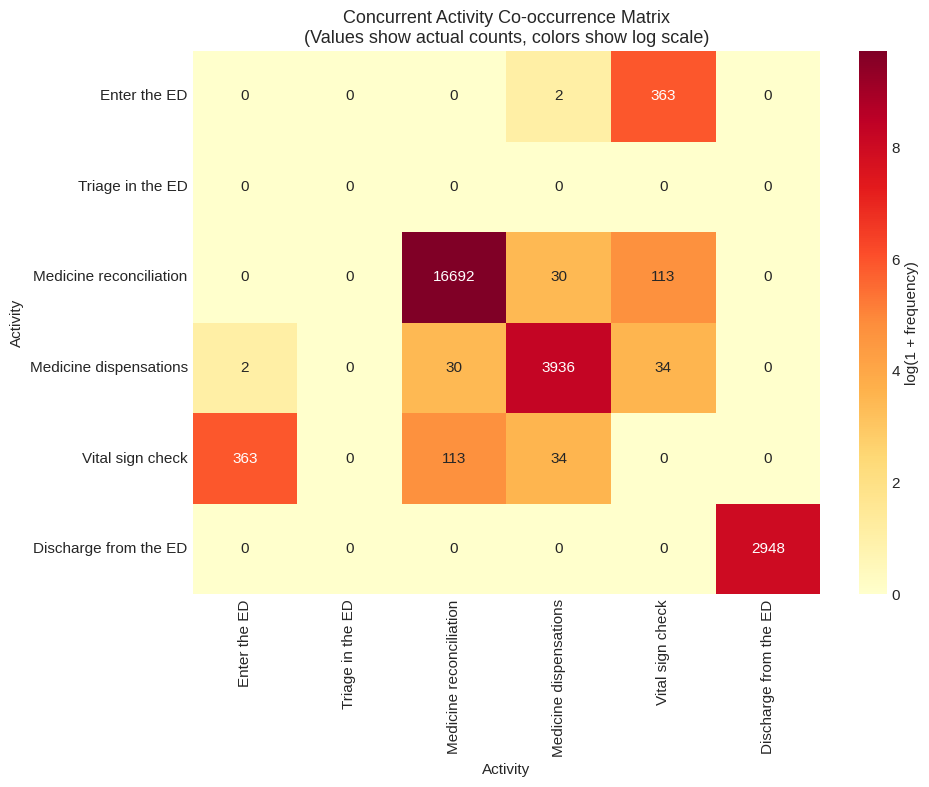

In [6]:
from data_validation import detect_concurrent_activities,create_concurrent_heatmap

concurrent_df, concurrent_cases, concurrent_pairs = detect_concurrent_activities(complete_log)
create_concurrent_heatmap(concurrent_pairs, complete_log)

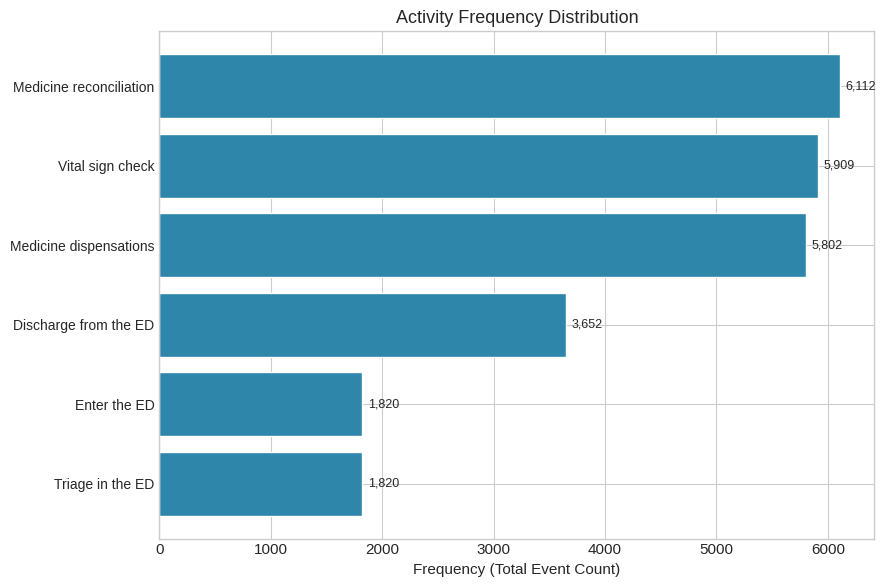

In [7]:
from data_validation import plot_activity_frequency
plot_activity_frequency(complete_log)

In [8]:
from preprocessor import aggregate_event_log

aggregated_log = aggregate_event_log(complete_log)


STEP 3: CONCURRENT/PARALLEL ACTIVITIES DETECTION

    Identifying events at exactly the same timestamp within cases...
    Concurrent activities indicate parallel execution or batch recording.
    

✓ RESULTS:
  - Cases with concurrent activities: 1,013 / 1,820 (55.7%)
  - Total concurrent activity groups: 1,619
  - Average activities per concurrent group: 2.18
  - Maximum concurrent activities: 6

  Top 10 most common concurrent activity pairs:
    Medicine dispensations ‖ Medicine dispensations: 1,100 times
    Medicine reconciliation ‖ Medicine reconciliation: 741 times
    Enter the ED ‖ Vital sign check: 363 times
    Medicine reconciliation ‖ Vital sign check: 43 times
    Medicine dispensations ‖ Vital sign check: 23 times
    Medicine dispensations ‖ Medicine reconciliation: 10 times
    Enter the ED ‖ Medicine dispensations: 1 times

    INTERPRETATION:
    - High concurrency suggests batch recording or parallel clinical activities
    - Same-activity concurrency (e.g., multi

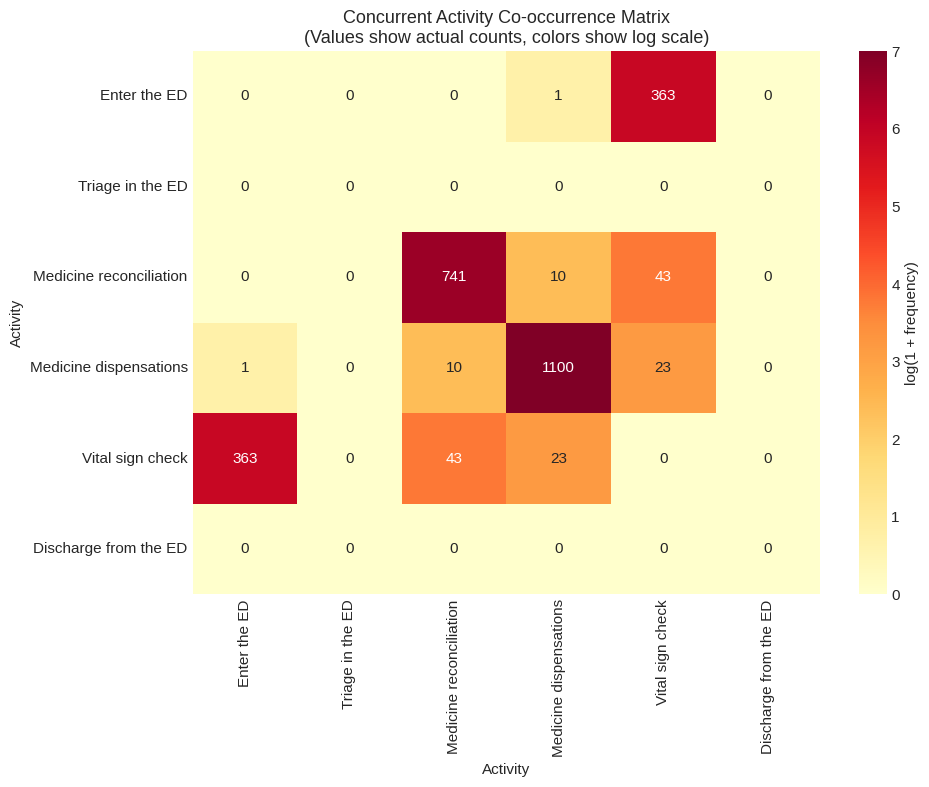

In [9]:
from data_validation import detect_concurrent_activities,create_concurrent_heatmap

concurrent_df, concurrent_cases, concurrent_pairs = detect_concurrent_activities(aggregated_log)
create_concurrent_heatmap(concurrent_pairs, aggregated_log)

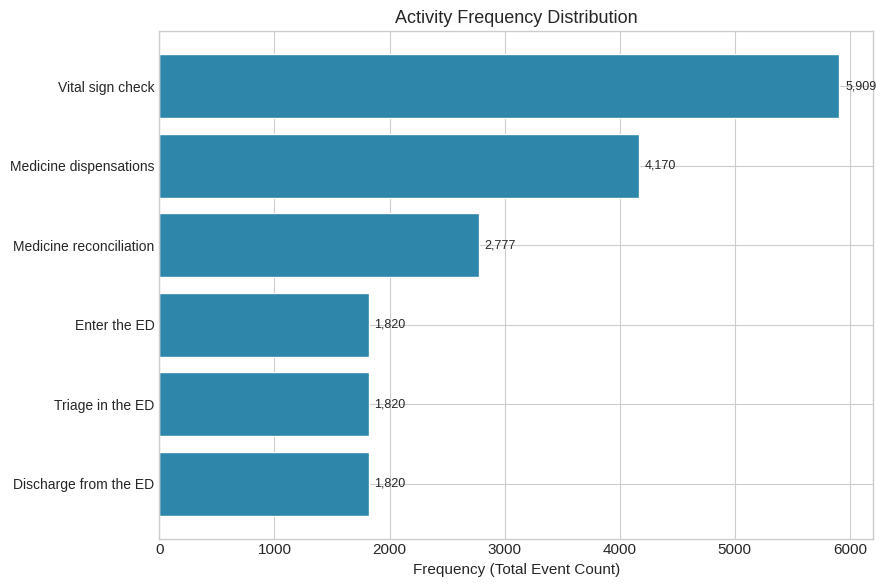

In [9]:
from data_validation import plot_activity_frequency
plot_activity_frequency(aggregated_log)

## 2. Performance analysis

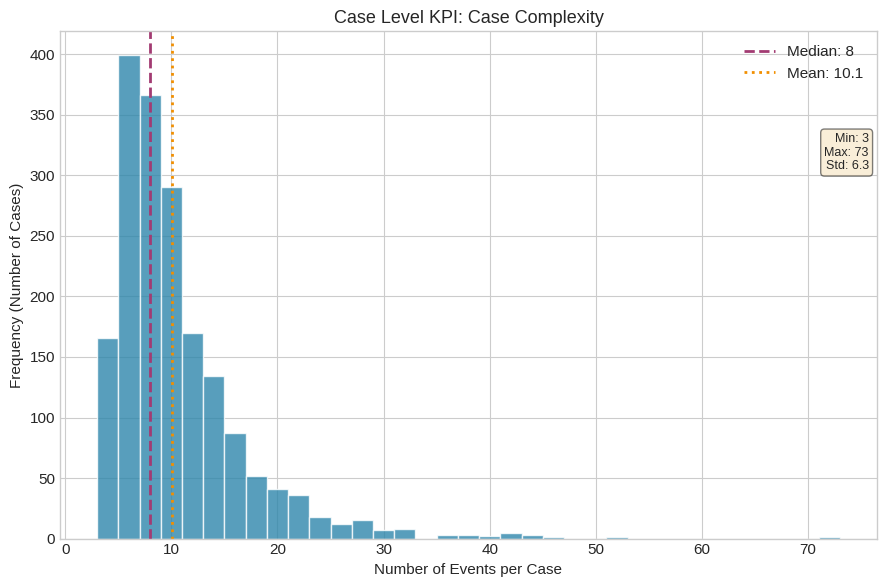

In [10]:
from kpi_calculation import plot_case_length_distribution
plot_case_length_distribution(aggregated_log)

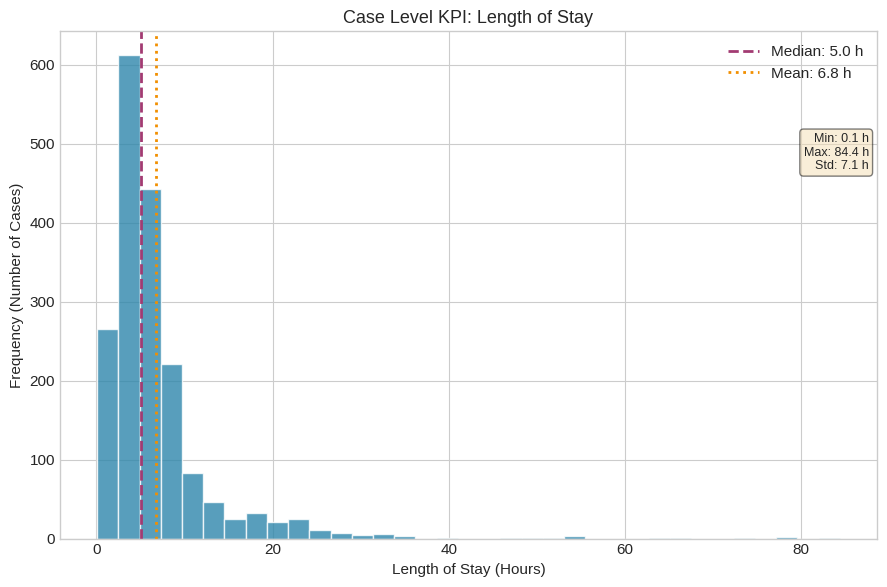

In [15]:
from kpi_calculation import plot_case_los_distribution
plot_case_los_distribution(aggregated_log)

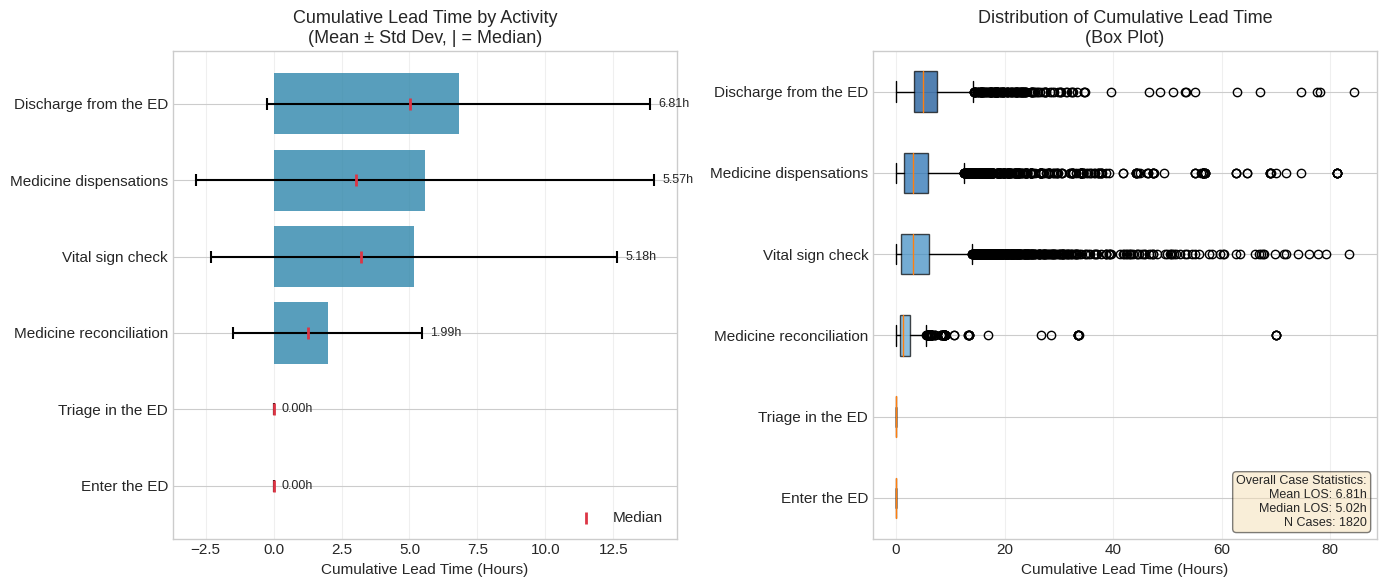


CUMULATIVE LEAD TIME SUMMARY (Hours)

Activity                             Mean     Median        Std        N
----------------------------------------------------------------------
Enter the ED                         0.00       0.00       0.00     1820
Triage in the ED                     0.00       0.00       0.00     1820
Medicine reconciliation              1.99       1.25       3.48     2777
Vital sign check                     5.18       3.20       7.47     5909
Medicine dispensations               5.57       3.05       8.43     4170
Discharge from the ED                6.81       5.02       7.06     1820


In [13]:
from kpi_calculation import plot_cumulative_lead_time
plot_cumulative_lead_time(aggregated_log)

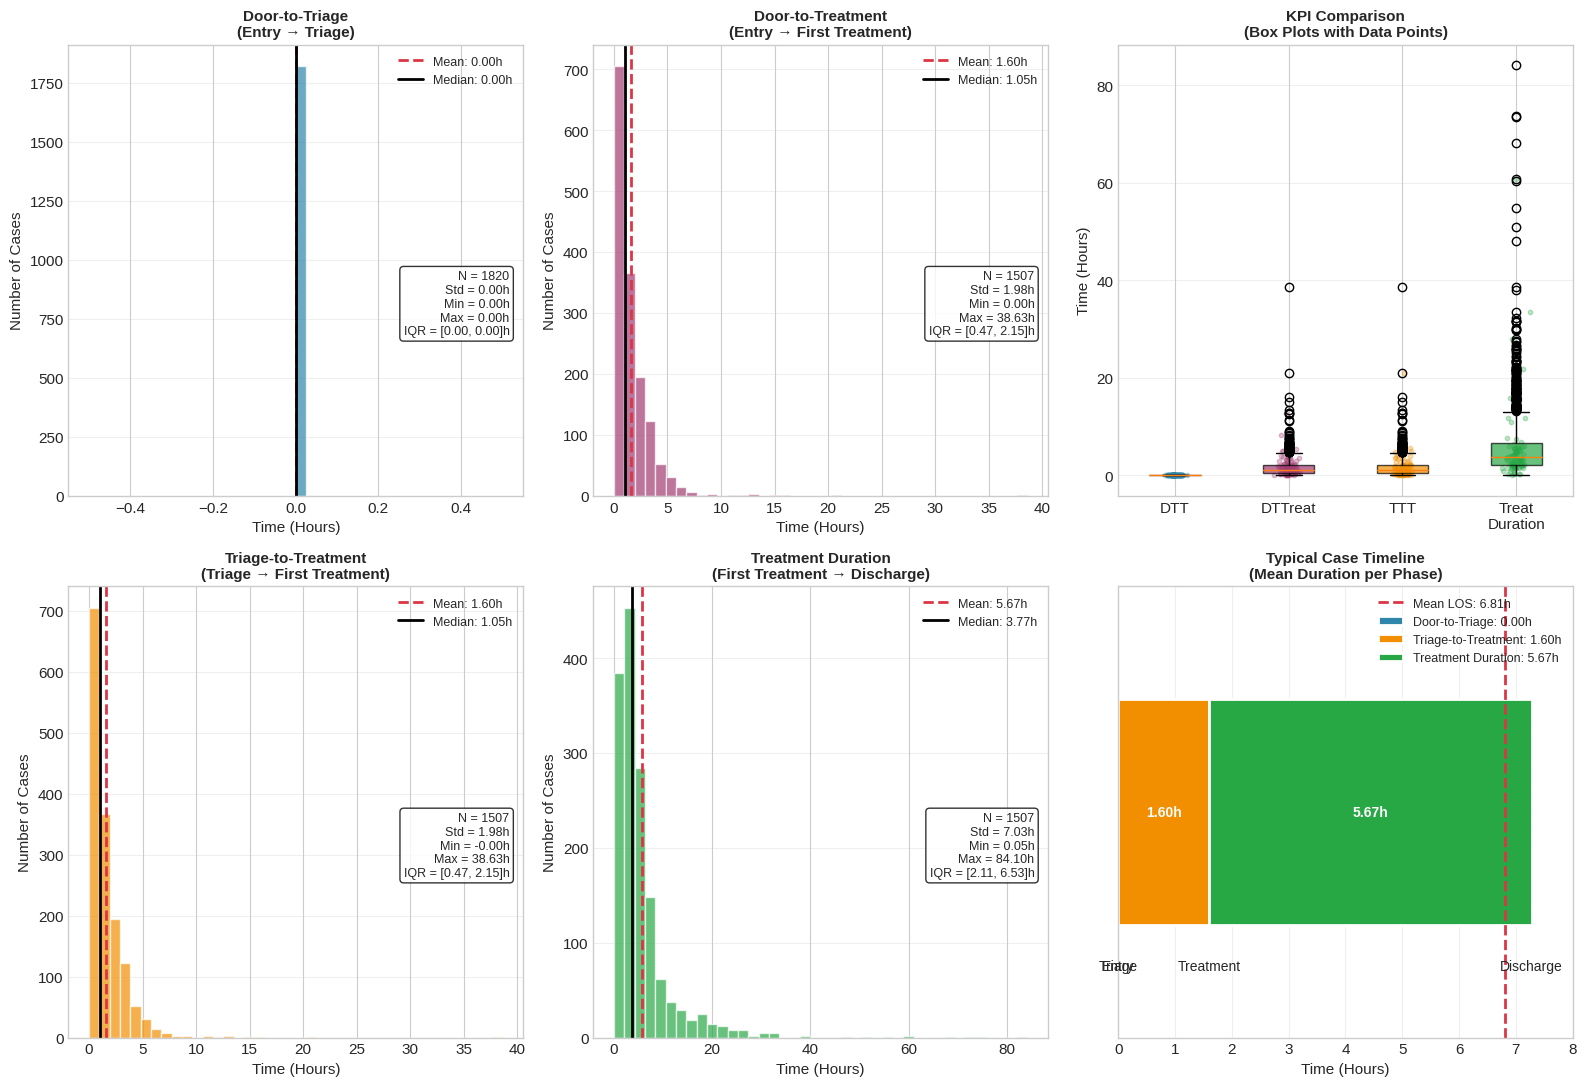


DOMAIN-SPECIFIC KPIs SUMMARY (Hours)

KPI                                  Mean     Median        Std        N
----------------------------------------------------------------------
Door-to-Triage                       0.00       0.00       0.00     1820
Door-to-Treatment                    1.60       1.05       1.98     1507
Triage-to-Treatment                  1.60       1.05       1.98     1507
Treatment Duration                   5.67       3.77       7.03     1507


In [5]:
from kpi_calculation import plot_domain_specific_kpis

plot_domain_specific_kpis(aggregated_log)

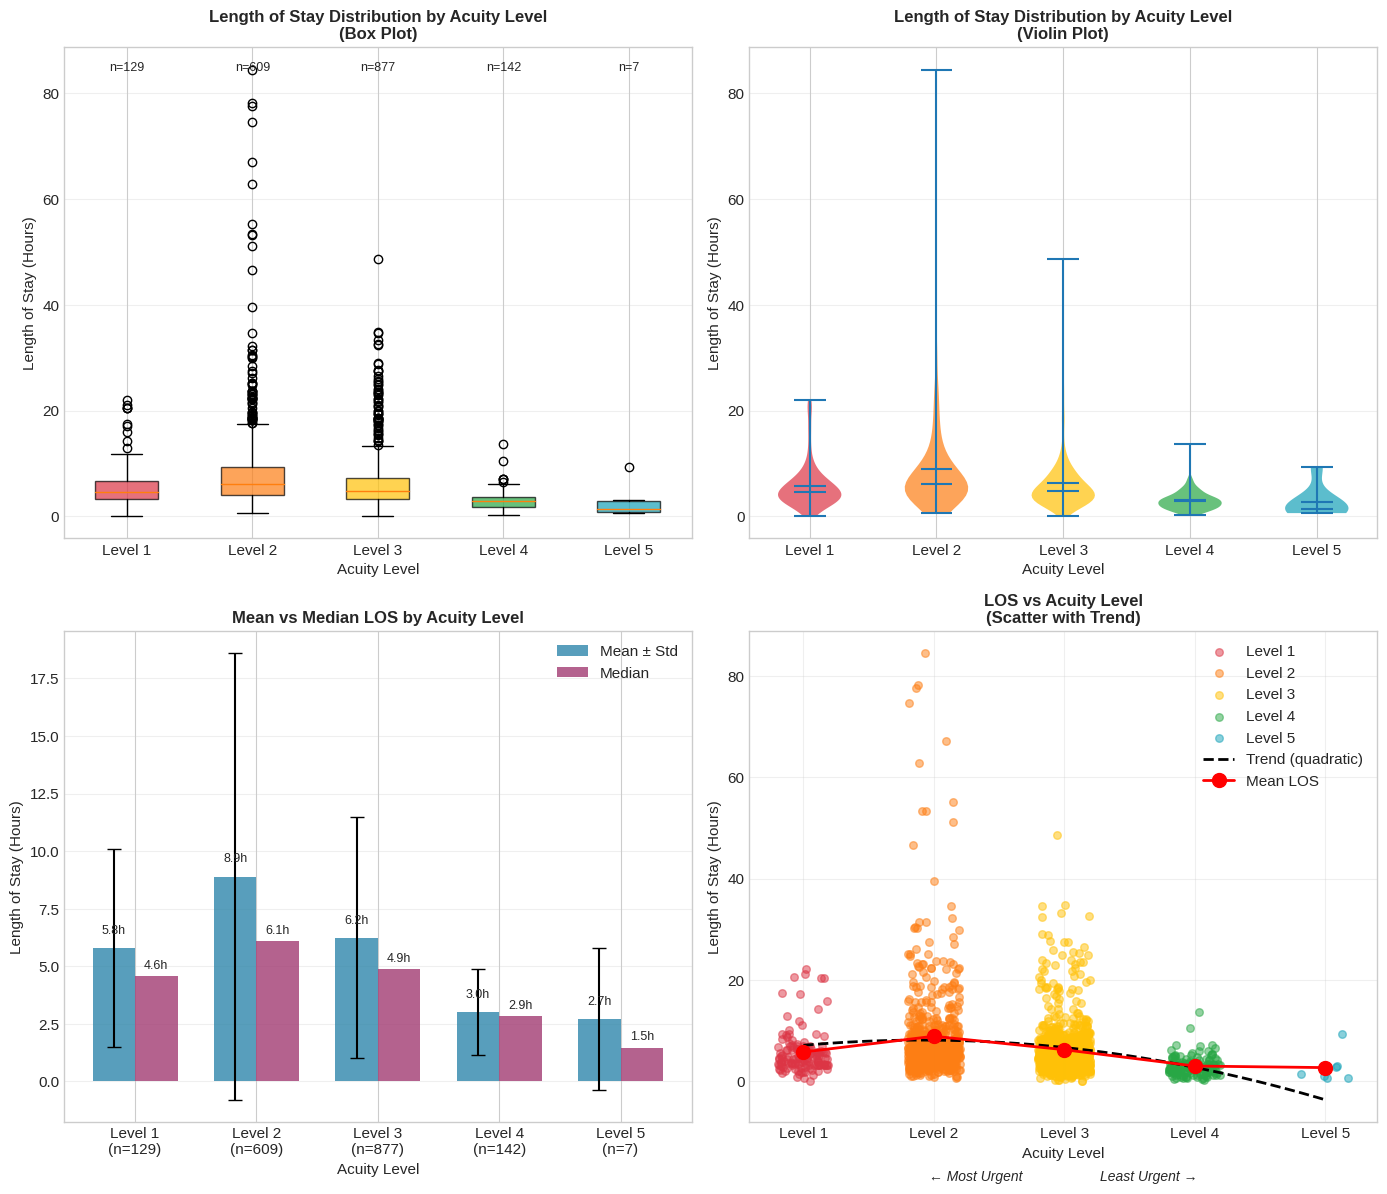


LENGTH OF STAY BY ACUITY LEVEL - STATISTICAL ANALYSIS

  DESCRIPTIVE STATISTICS (Hours):
  ------------------------------------------------------------
  Acuity                 N       Mean     Median        Std
  ------------------------------------------------------------
  Level 1              129       5.78       4.58       4.30
  Level 2              609       8.90       6.10       9.69
  Level 3              877       6.24       4.87       5.24
  Level 4              142       3.02       2.85       1.86
  Level 5                7       2.71       1.47       3.07

  KRUSKAL-WALLIS TEST:
    H-statistic: 207.77
    p-value: 8.01e-44
    → Significant difference in LOS across acuity levels (p < 0.05)


In [16]:
from kpi_calculation import plot_los_by_acuity

plot_los_by_acuity(aggregated_log)

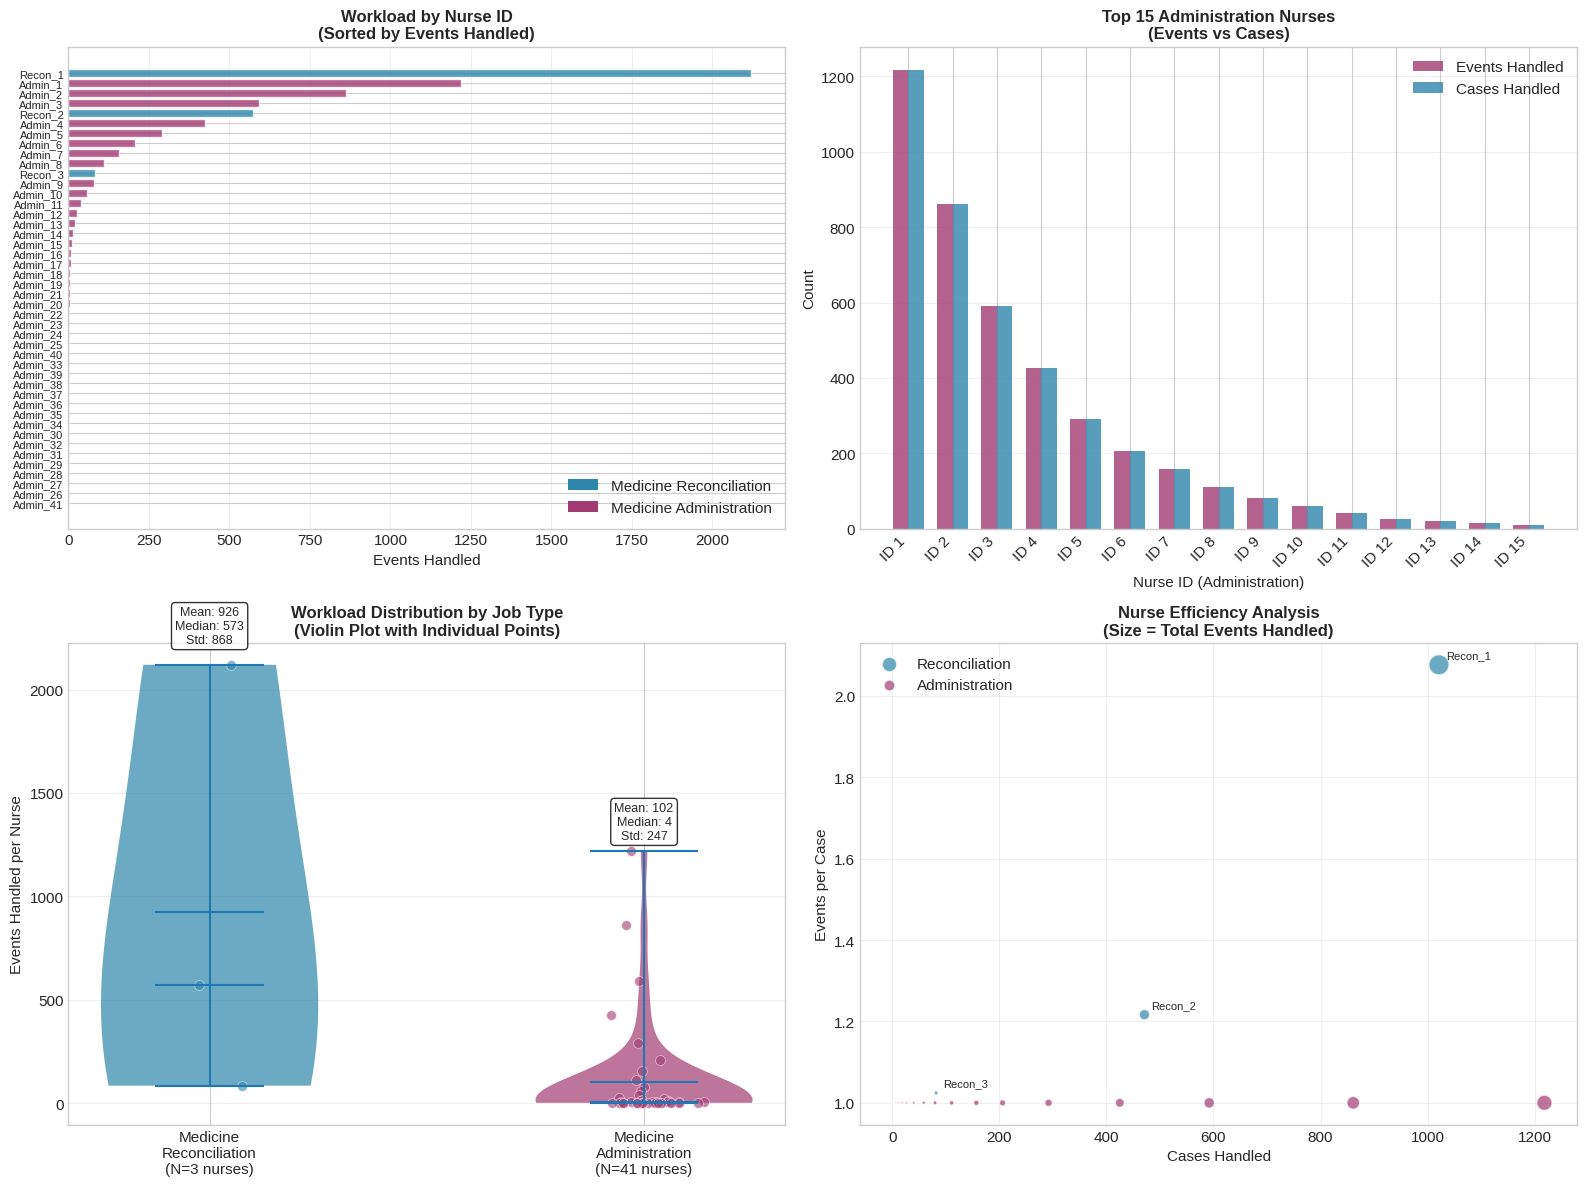


NURSE WORKLOAD SUMMARY

  MEDICINE RECONCILIATION NURSES:
  ------------------------------------------------------------
  Nurse ID              Events        Cases     Events/Case
  Recon_1                 2120         1021            2.08
  Recon_2                  573          471            1.22
  Recon_3                   84           82            1.02

  MEDICINE ADMINISTRATION NURSES (Top 10):
  ------------------------------------------------------------
  Nurse ID              Events        Cases     Events/Case
  Admin_1                 1218         1218            1.00
  Admin_2                  861          861            1.00
  Admin_3                  592          592            1.00
  Admin_4                  425          425            1.00
  Admin_5                  292          292            1.00
  Admin_6                  206          206            1.00
  Admin_7                  157          157            1.00
  Admin_8                  111          111        

In [12]:
from kpi_calculation import plot_nurse_workload

plot_nurse_workload(aggregated_log)


VARIANT ANALYSIS

  Total cases: 1,820
  Total unique variants: 973
  Variants per case: 0.535

  Pareto Analysis:
    Top 20% of variants (195) cover 57.3% of cases
    609 variants needed to cover 80% of cases (62.6% of variants)

  Top 10 most frequent variants:
  ----------------------------------------------------------------------
     1. Freq:   77 (  4.2%) | Len:  4 | Cum: 4.2%
     2. Freq:   59 (  3.2%) | Len:  5 | Cum: 7.5%
     3. Freq:   49 (  2.7%) | Len:  3 | Cum: 10.2%
     4. Freq:   35 (  1.9%) | Len:  5 | Cum: 12.1%
     5. Freq:   31 (  1.7%) | Len:  6 | Cum: 13.8%
     6. Freq:   26 (  1.4%) | Len:  6 | Cum: 15.2%
     7. Freq:   23 (  1.3%) | Len:  5 | Cum: 16.5%
     8. Freq:   23 (  1.3%) | Len:  5 | Cum: 17.7%
     9. Freq:   23 (  1.3%) | Len:  4 | Cum: 19.0%
    10. Freq:   22 (  1.2%) | Len:  6 | Cum: 20.2%

------------------------------------------------------------
  POWER-LAW DISTRIBUTION TEST
------------------------------------------------------------

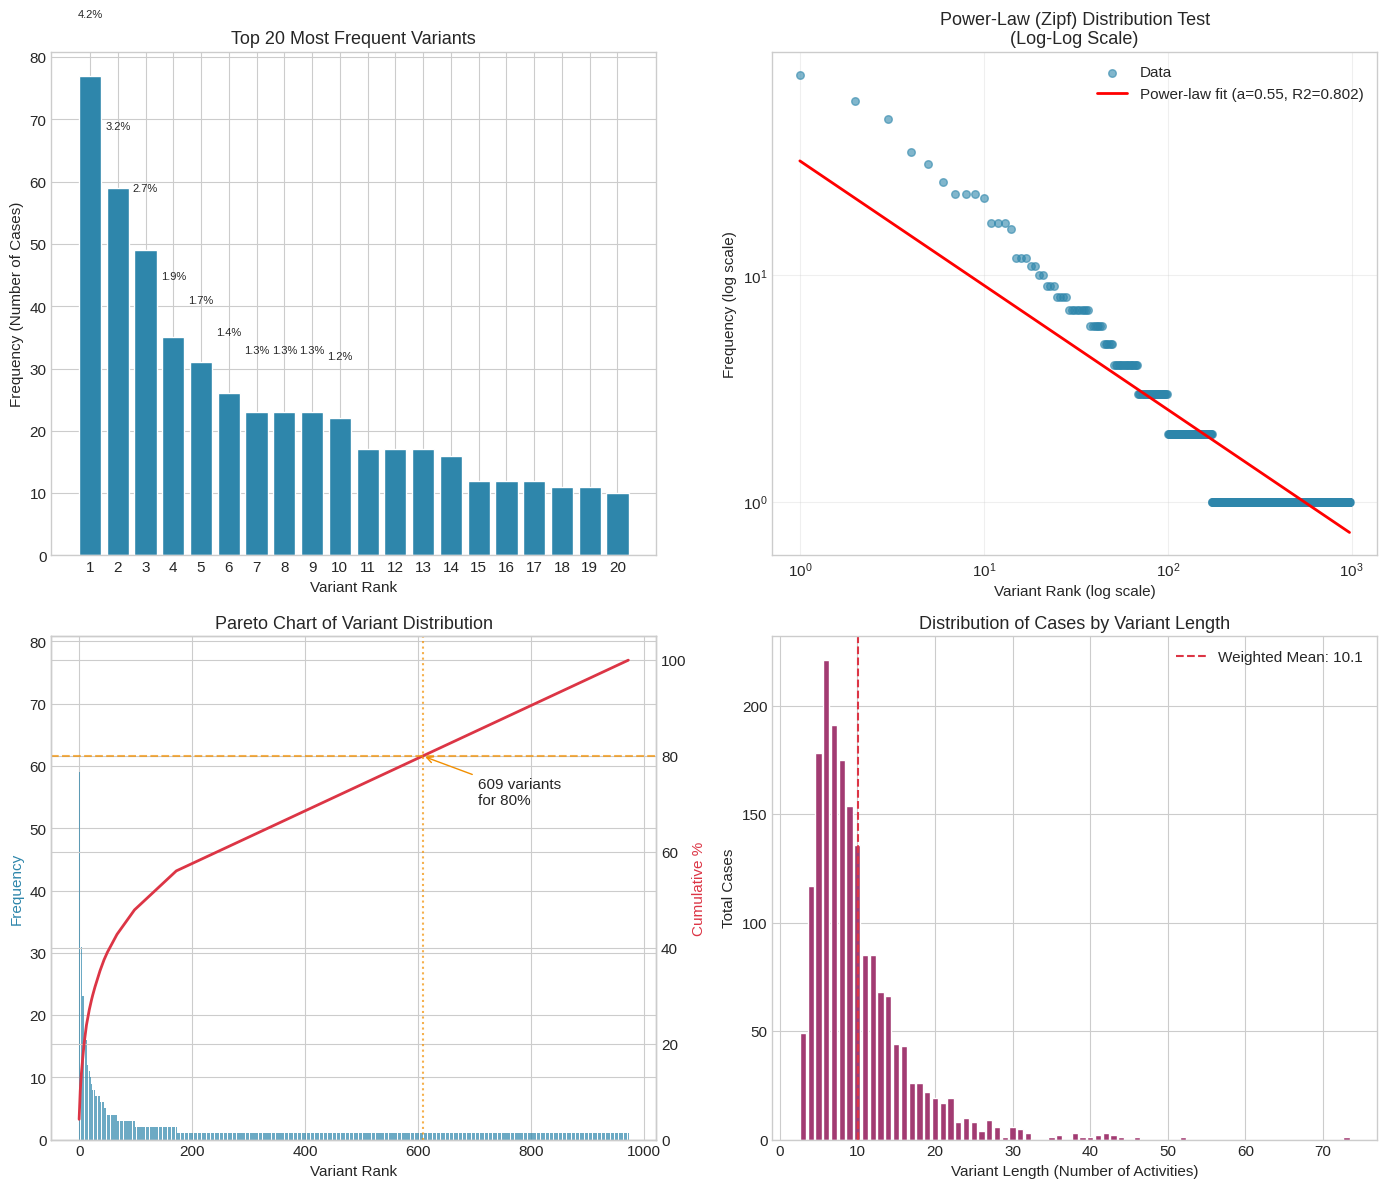

In [7]:
from variant_analysis import perform_sequential_variant_analysis
perform_sequential_variant_analysis(aggregated_log)

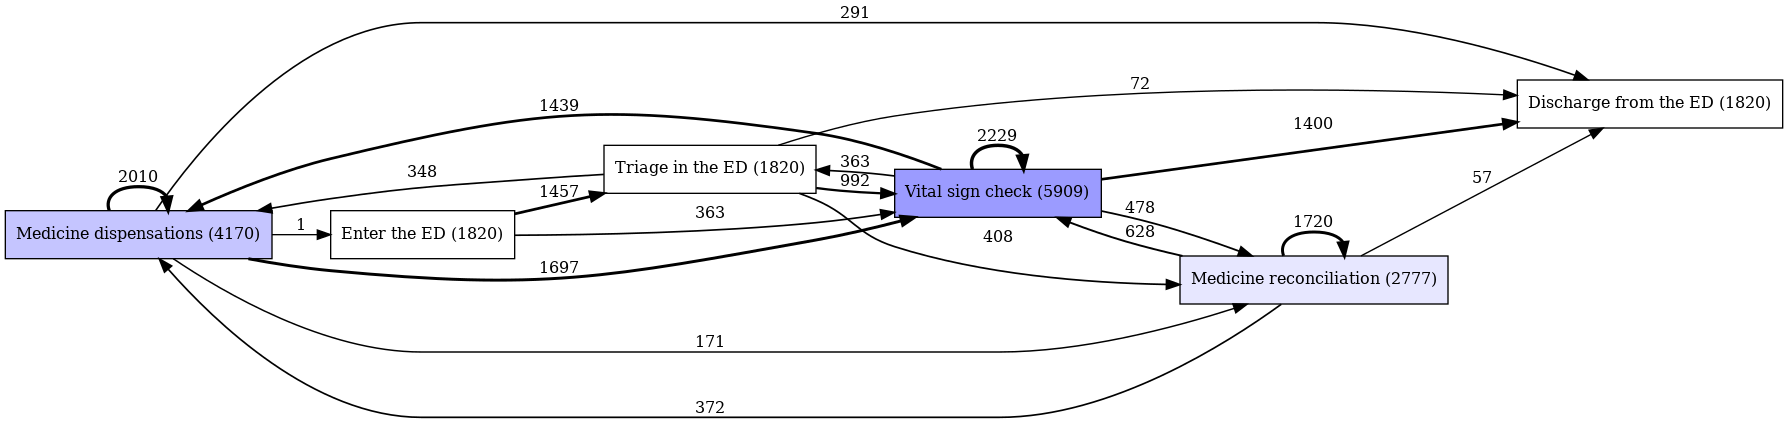

In [22]:
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_visualization

# 2. Discover the DFG
dfg = dfg_discovery.apply(aggregated_log)

# 3. Visualize DFG
gviz = dfg_visualization.apply(dfg, log=aggregated_log, variant=dfg_visualization.Variants.FREQUENCY)
dfg_visualization.view(gviz)

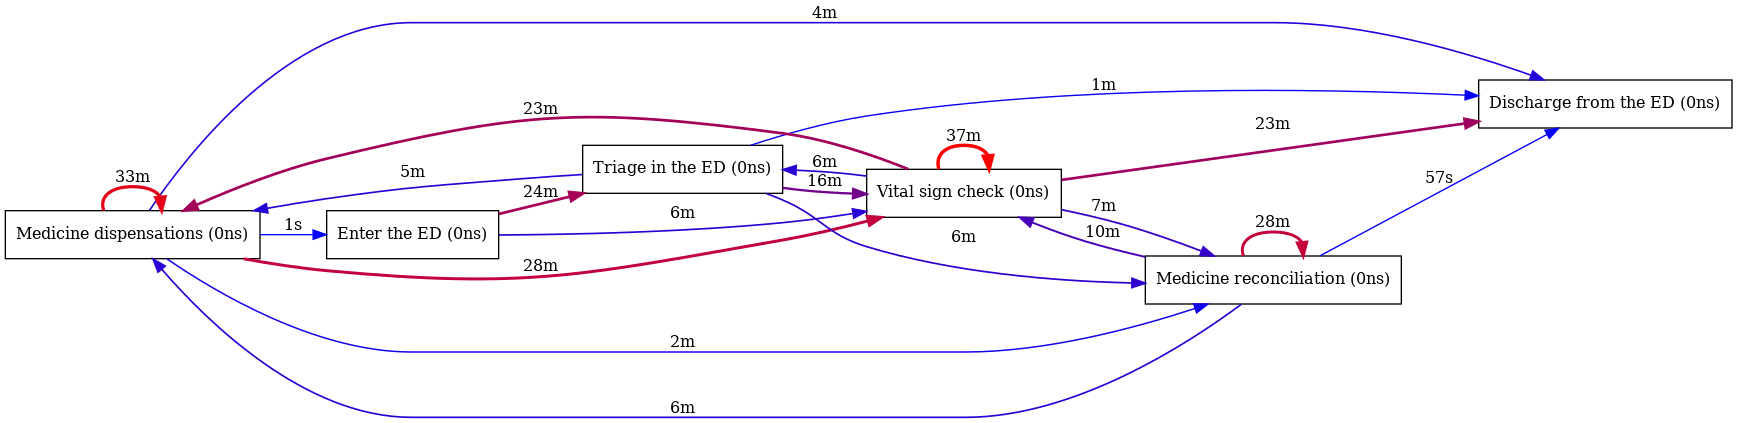

In [23]:
gviz = dfg_visualization.apply(dfg, log=aggregated_log, variant=dfg_visualization.Variants.PERFORMANCE)
dfg_visualization.view(gviz)

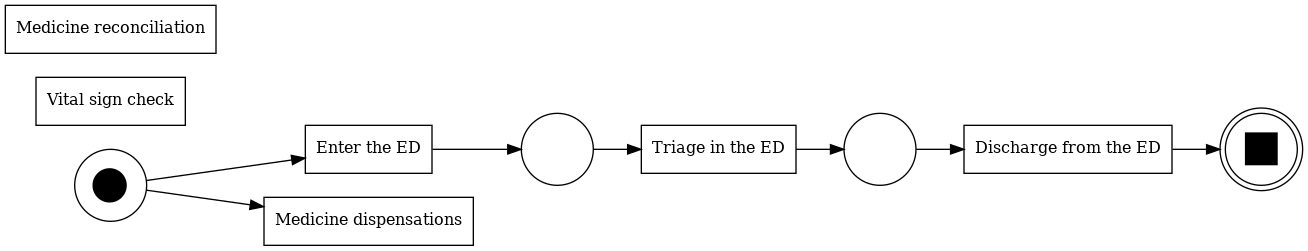

In [21]:
# visulization of Alpha miner 
net, initial_marking, final_marking = pm4py.discover_petri_net_alpha(
    aggregated_log
)
pm4py.view_petri_net(net,initial_marking,final_marking)

In [ ]:
from process_discovery import perform_process_discovery

perform_process_discovery(aggregated_log)

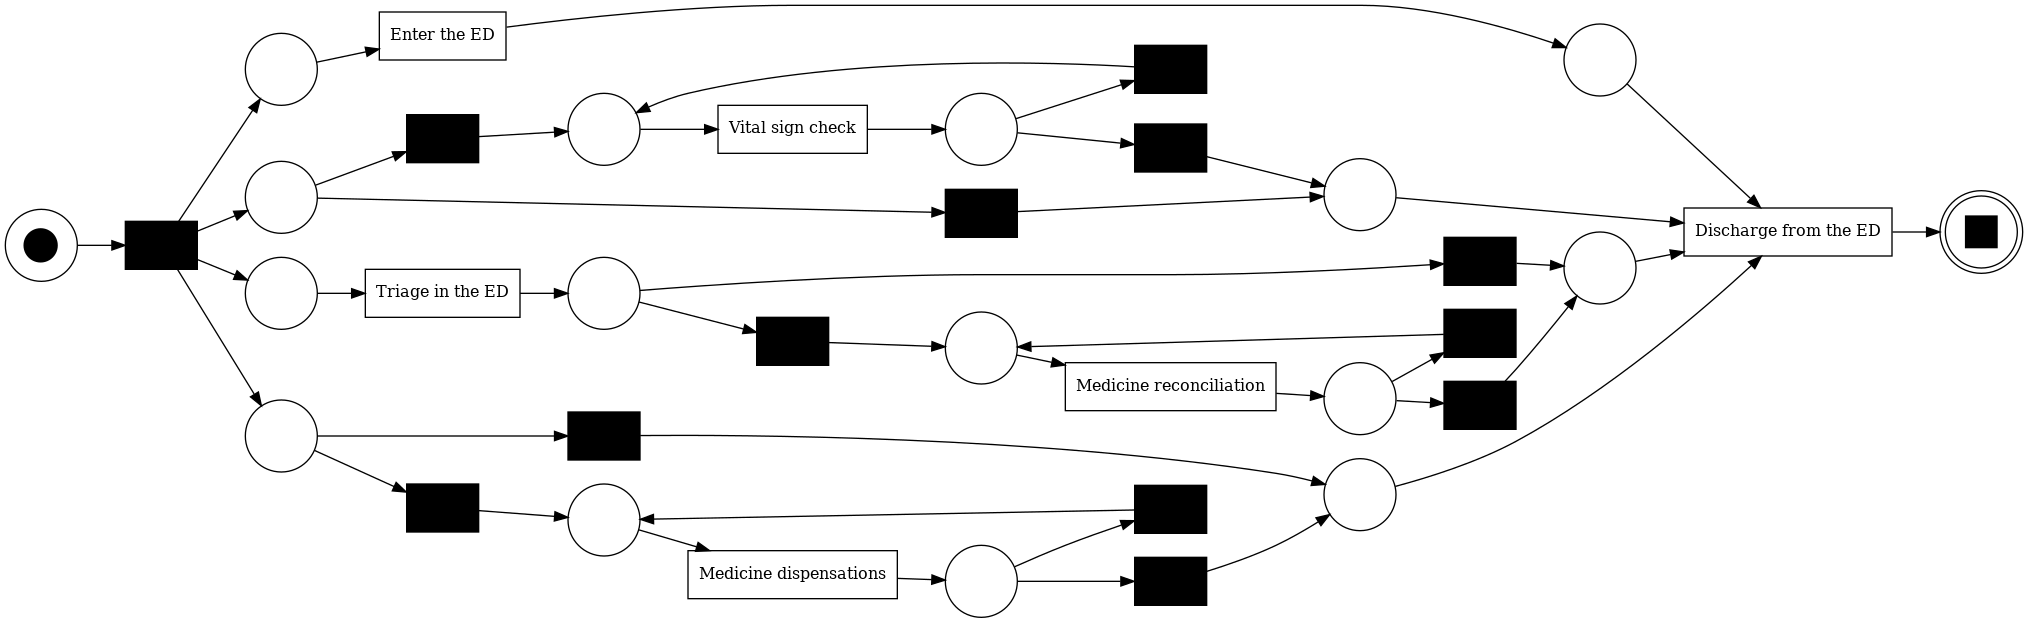

In [14]:
# 2. Discover the model using the Inductive Miner
# This returns the Petri net (net), Initial Marking (im), and Final Marking (fm)
net, im, fm = pm4py.discover_petri_net_inductive(aggregated_log)

# 3. Visualize the result
pm4py.view_petri_net(net, im, fm)

PATTERN-BASED FEATURE GENERATION & CLUSTERING

Dataset: 25115 events, 1820 cases

[Step 1] Generating binary features (aggregation: any)...
    Created 12 features for 1820 cases
    Features: fever, tachycardia, tachypnea, hypoxemia, high_sbp, high_dbp, has_pain, arrival_by_ambulance, arrival_by_walk_in, arrival_by_helicopter, has_received_medicine, high_acuity

[Step 3] Performing K-Medoids clustering (k=4)...
    Silhouette Score: 0.2864
    Calinski-Harabasz Index: 348.4

[Step 4] Compiling results...

CLUSTER MEDOIDS (Representative Cases)

Cluster 0: 843 cases (46.3%)
  Medoid Case ID: 30339284
  Active Features: high_sbp, arrival_by_ambulance, has_received_medicine, high_acuity
  Trace Length: 13

Cluster 1: 301 cases (16.5%)
  Medoid Case ID: 30016618
  Active Features: tachycardia, high_sbp, high_dbp, has_pain, arrival_by_walk_in, has_received_medicine, high_acuity
  Trace Length: 11

Cluster 2: 676 cases (37.1%)
  Medoid Case ID: 30023012
  Active Features: high_sbp, high_dbp

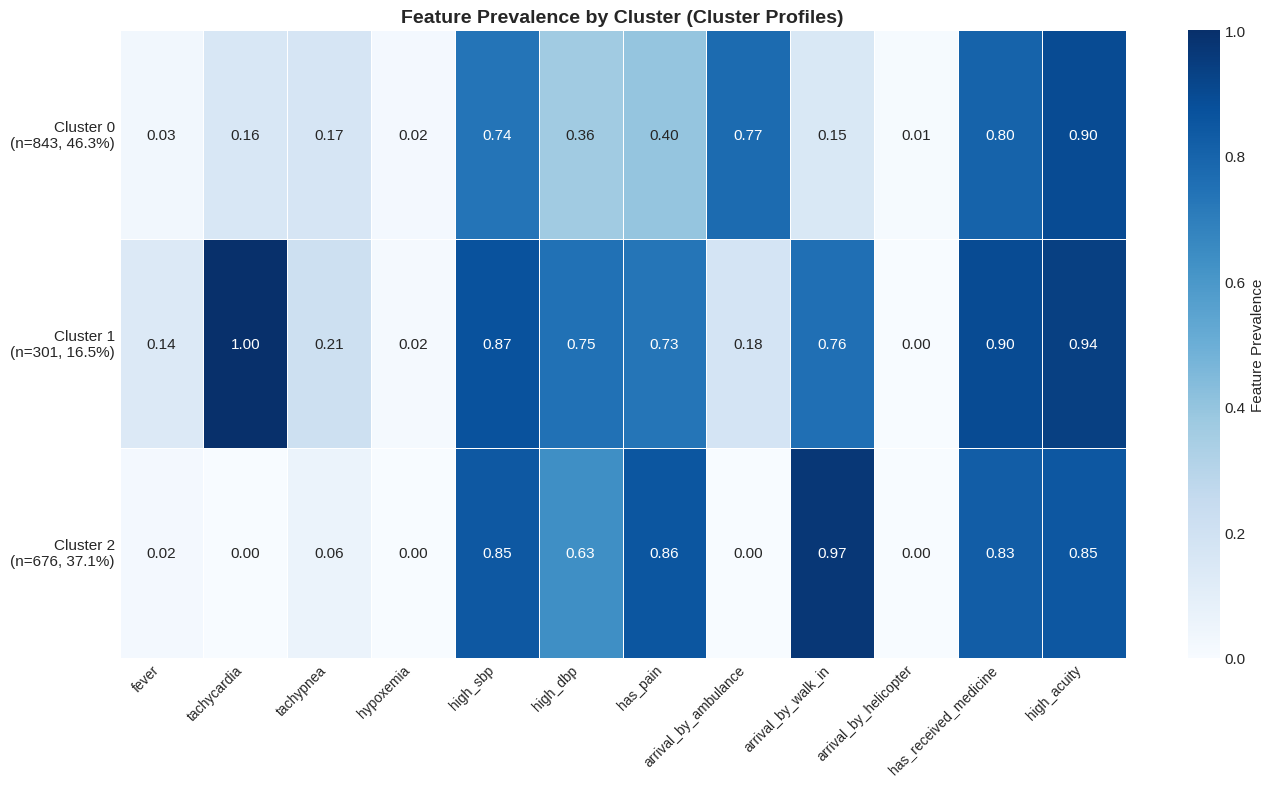

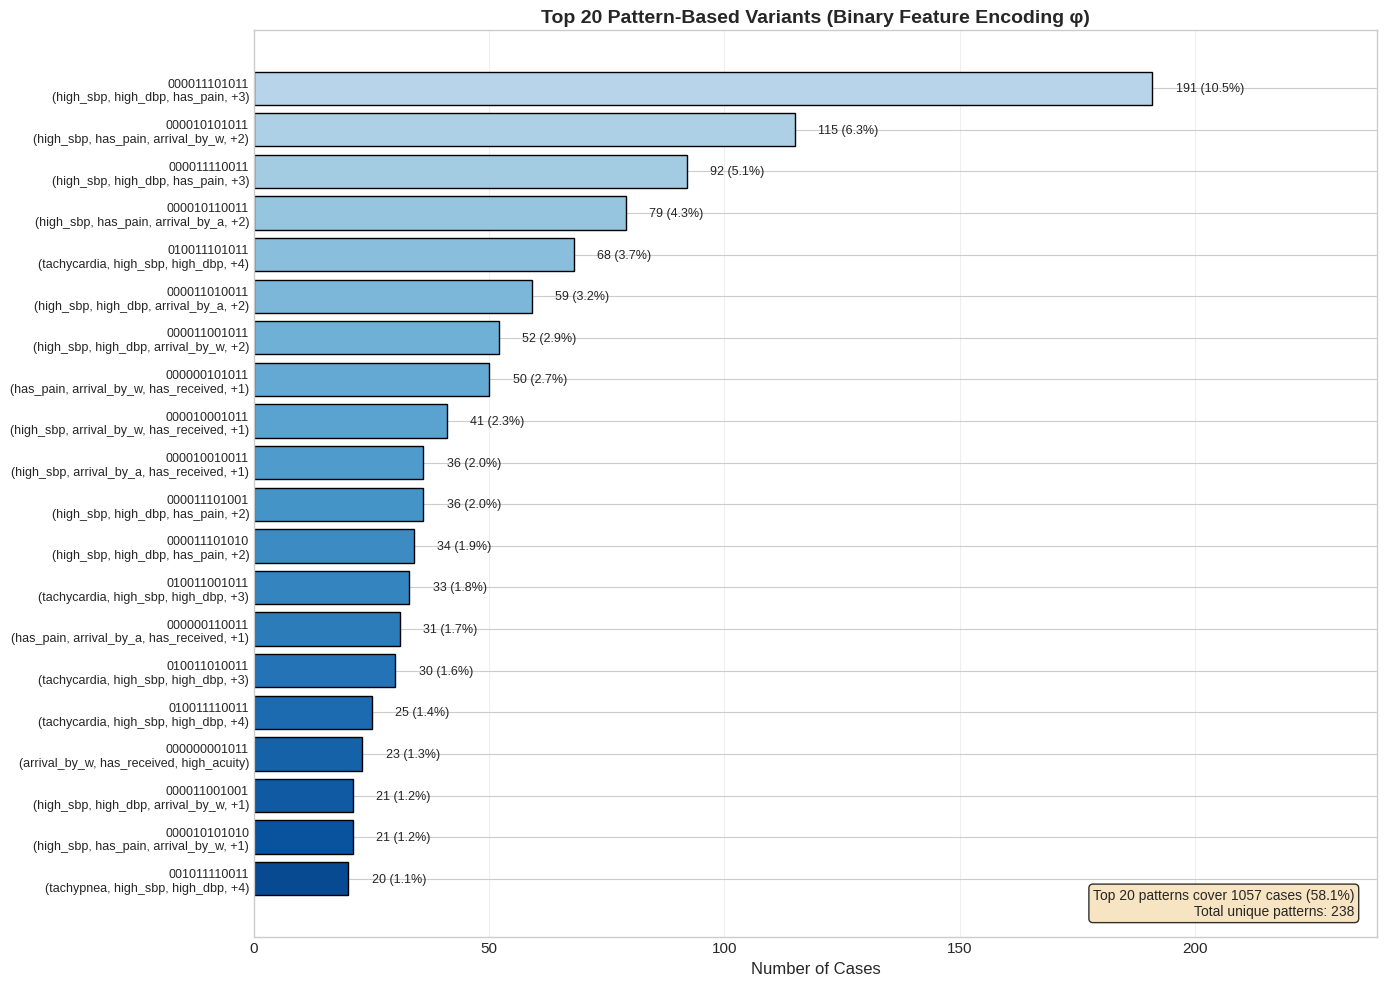

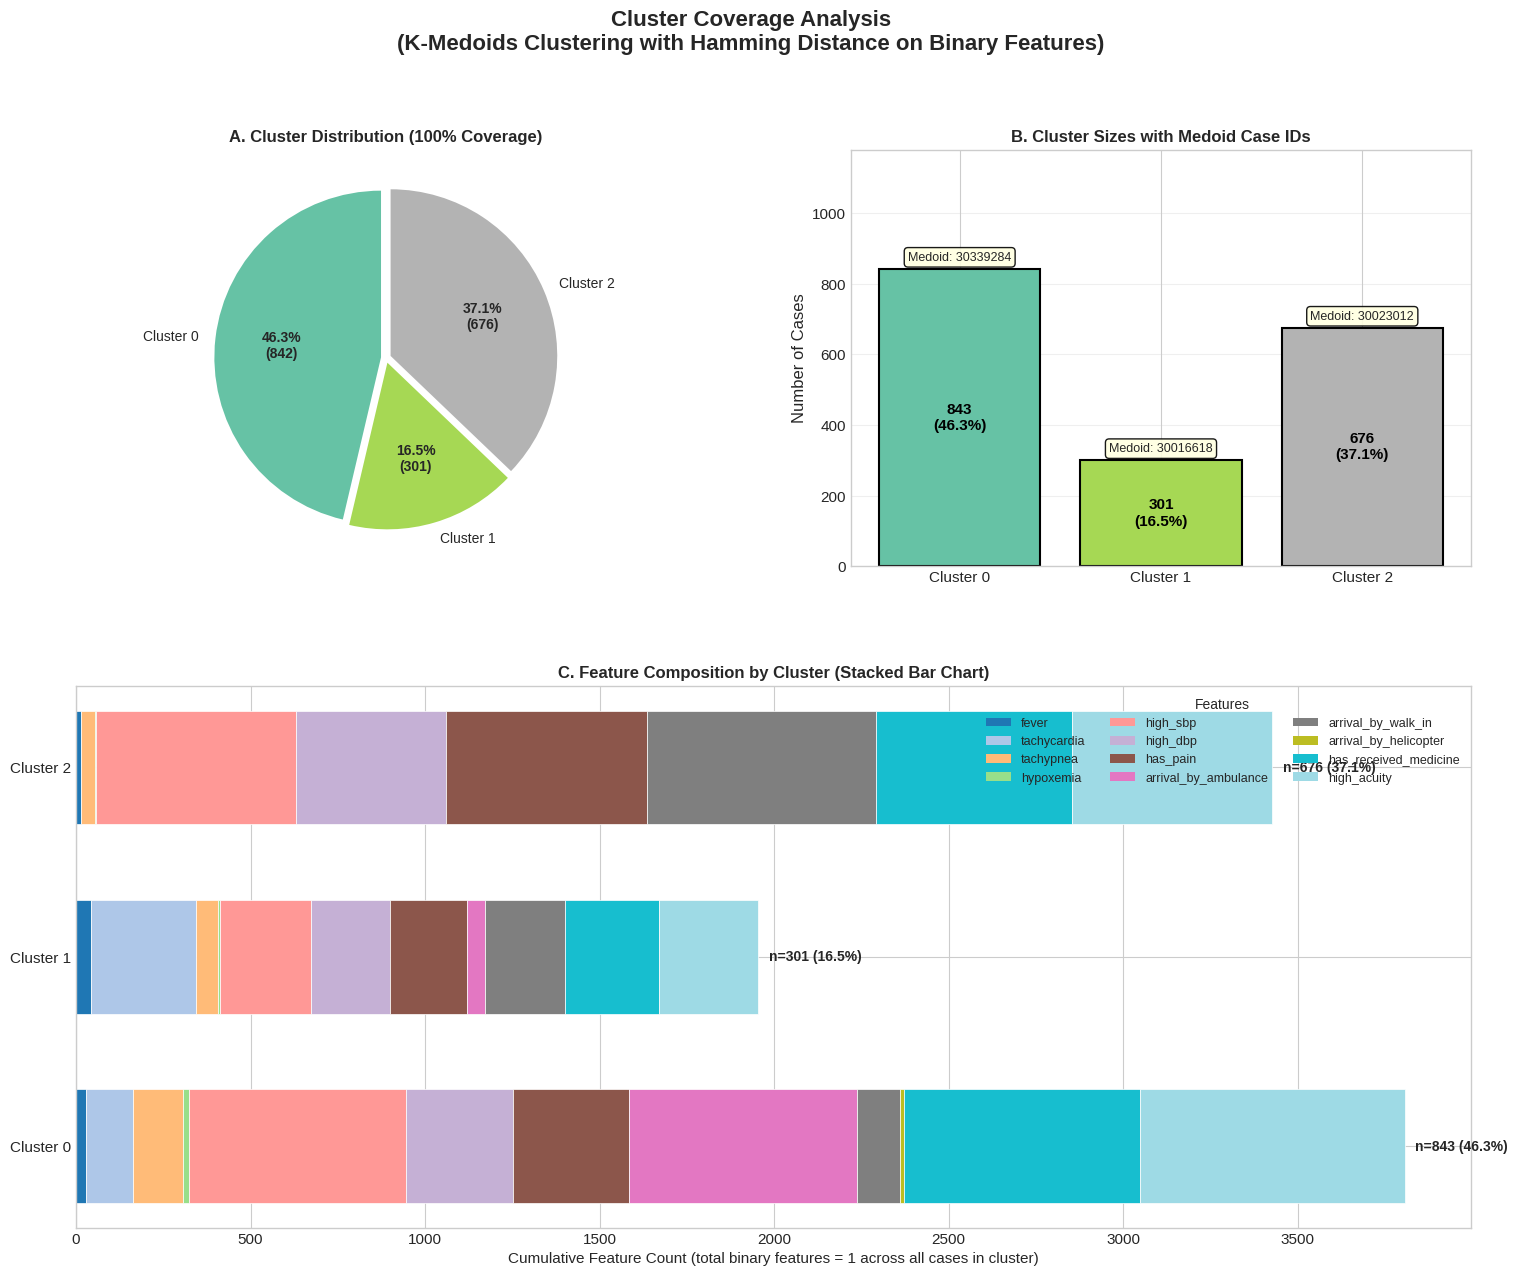

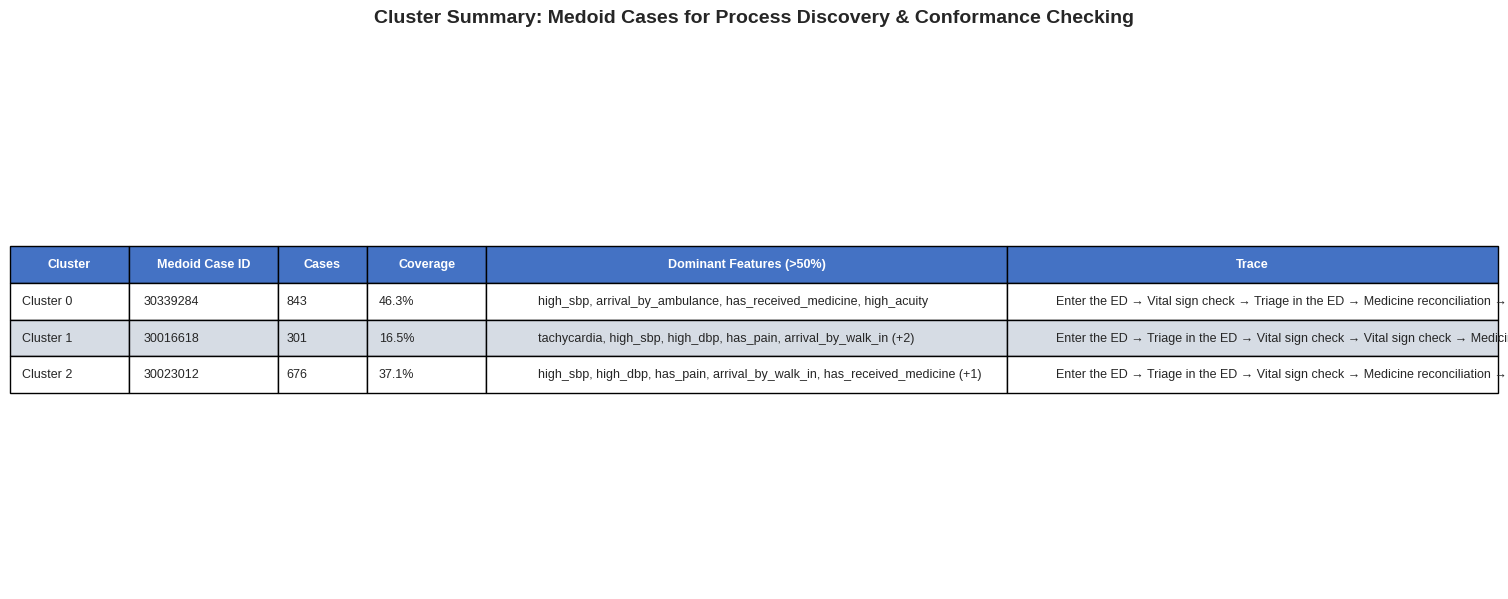

In [3]:
from feature_based_variant_analysis import (
    perform_feature_based_variant_clustering,
    plot_cluster_profiles,
    plot_pattern_variants,
    plot_cluster_coverage,
    plot_cluster_summary_table,
    generate_all_visualizations
)
import pandas as pd

# Perform clustering
medoid_case_ids, results = perform_feature_based_variant_clustering(
    log=df,
    case_id_col='stay_id',
    activity_col='activity',
    timestamp_col='time',
    n_clusters=4
)

# Generate all visualizations at once
output_files = generate_all_visualizations(
    feature_matrix=results['feature_matrix'],
    feature_names=results['feature_names'],
    medoid_case_ids=medoid_case_ids,
    results=results,
)